# [LAB-10] 2-2. 결과보고 모듈화

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *
from pandas import DataFrame
from IPython.display import Markdown, display

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기 및 전처리

1단원과 **동일한 데이터**를 사용한다.

In [2]:
origin = load_data('iris_bin')

# 종속변수 라벨링 (versicolor = 0, virginica = 1)
df = my_prep.labeling(origin, columns=['Species'])

df.head()

📚 아이리스 데이터셋을 이진분류 예제용으로 종속변수의 종류를 2개로 변경한 데이터 (Kaggle의 데이터셋을 직접 수정함)

    field         description
--  ------------  ----------------------------
 0  Sepal_Length  꽃받침 길이
 1  Sepal_Width   꽃받침 너비
 2  Petal_Length  꽃잎 길이
 3  Petal_Width   꽃잎 너비
 4  Species       품종 (versicolor, virginica)

Species (2종): versicolor=0, virginica=1


,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
0,7.000,3.200,4.700,1.400,0
1,6.400,3.200,4.500,1.500,0
2,6.900,3.100,4.900,1.500,0
3,5.500,2.300,4.000,1.300,0
4,6.500,2.800,4.600,1.500,0


### 3. 단순 로지스틱 회귀 모형 적합

- 이 결과에서 모형 적합도에 필요한 정보를 추출하고 오즈를 계산해야 한다.

In [3]:
data1 = df[['Sepal_Length', 'Species']]
fit1 = my_logit.fit_model(data1, y='Species', summary=True)

                           Logit Regression Results                           
Dep. Variable:                Species   No. Observations:                  100
Model:                          Logit   Df Residuals:                       98
Method:                           MLE   Df Model:                            1
Date:                Thu, 30 Jul 2026   Pseudo R-squ.:                  0.2026
Time:                        06:34:30   Log-Likelihood:                -55.273
converged:                       True   LL-Null:                       -69.315
Covariance Type:            nonrobust   LLR p-value:                 1.162e-07
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.5708      2.907     -4.325      0.000     -18.268      -6.873
Sepal_Length     2.0129      0.465      4.325      0.000       1.101       2.925


## #02. 모듈화 기능 확인

### 1. 모형 적합도

In [4]:
display(Markdown(my_logit.report_fitness(fit1)))

**Note. n = 100. LL = -55.273, LL-Null = -69.315, LLR χ²(1) = 28.083, p < 0.001, Pseudo R² = 0.203**

Species를 종속변수로, Sepal_Length(을)를 독립변수로 한 이항 로지스틱 회귀분석 결과, 모형은 통계적으로 유의하였다.

> LLR χ²(1) = 28.083, p < 0.001, Pseudo R² = 0.203.

즉, 모형의 유사결정계수는 0.203로 매우 우수한 적합 수준을 보였다.

> ※ Pseudo R²는 선형회귀의 R²처럼 '분산 설명 비율'로 해석하지 않는다. 일반적으로 **0.2~0.4** 구간이면 매우 우수한 적합으로 본다.

### 2. 오즈비 보고표

회귀계수·오즈비·95% 신뢰구간·VIF를 하나의 표로 정리한다. (단순모형이라 변수는 하나다.)

In [5]:
my_logit.report_variables(fit1, data1)

,종속변수,독립변수,B,βstd,표준오차,z,유의확률,오즈비(OR),OR 95% 하한,OR 95% 상한,공차,VIF
0,Species,Sepal_Length,2.013,1.334,0.465,4.325,0.000,7.485,3.006,18.637,1.000,1.000


### 3. 해석 문장 자동 생성

In [6]:
display(Markdown(my_logit.report_variables_text(fit1, data=data1)))

- **Sepal_Length**의 회귀계수는 **B = 2.0129**, 오즈비는 **OR = 7.4852**로 나타났으며, 이는 **Species**에 유의한 요인임을 의미한다. (**z = 4.32**, **p < .001**) 즉, **Sepal_Length**가 1 증가할 때 Species가 1(사건 발생)이 될 오즈는 평균적으로 약 **648.5% 증가**하는 것으로 해석된다.

> ※ 오즈비(OR)가 1보다 크면 사건 발생 오즈가 증가, 1보다 작으면 감소함을 뜻한다. 유의확률이 유의수준보다 큰(=유의하지 않은) 변수는 효과가 통계적으로 확인되지 않았으므로 오즈비 해석에 주의한다. 더미변수의 오즈비는 '기준(drop_first로 제외된) 범주' 대비 값이다.

### 4. 오즈비 시각화

- 오즈비를 가로 막대로 그린다.
- **OR = 1 기준선**을 넘는지가 핵심이다.

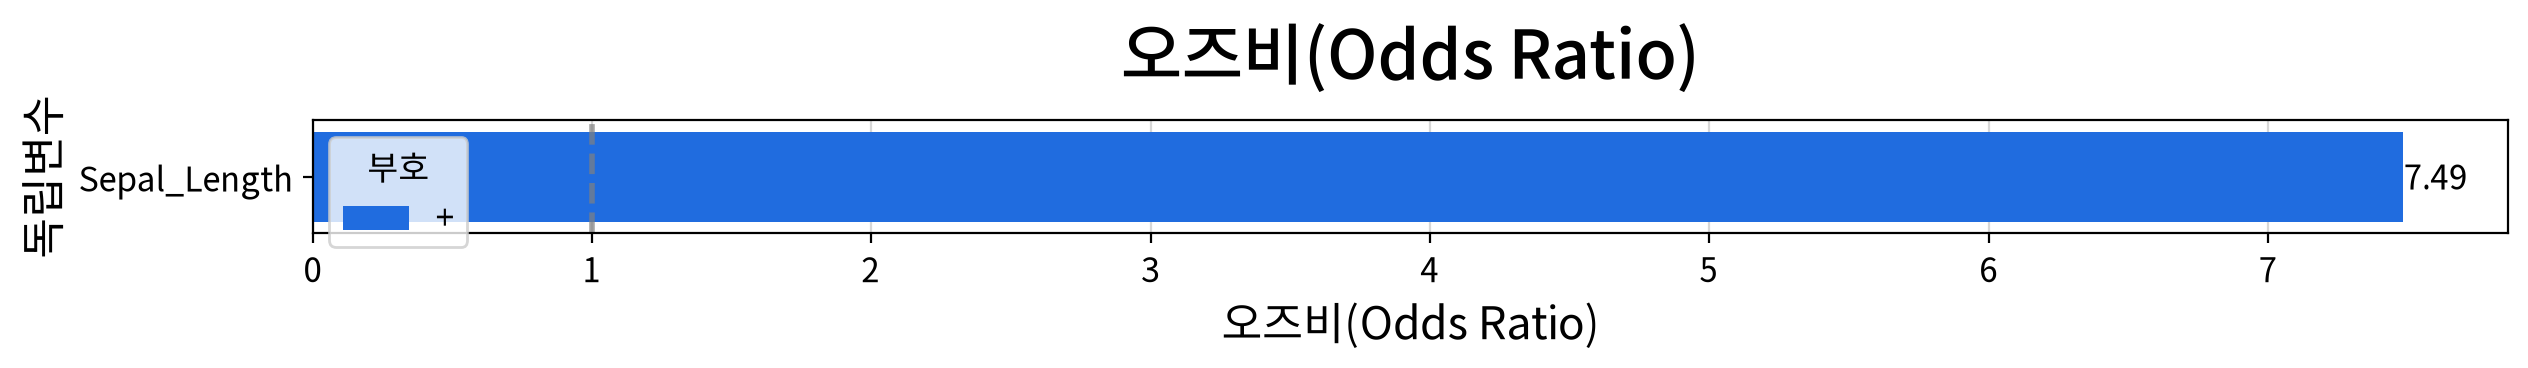

In [7]:
my_logit.plot_odds(fit1, data1, title='오즈비(Odds Ratio)', height=200)